In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ru-bridge-telegram/zarussia_1_green_df.csv
/kaggle/input/ru-bridge-telegram/Lunay14_green_df.csv
/kaggle/input/ru-bridge-telegram/ua_tribunal_red_df.csv
/kaggle/input/ru-bridge-telegram/bridge_full_msg_csv.csv
/kaggle/input/ru-bridge-telegram/domain_pc1.csv
/kaggle/input/ru-bridge-telegram/rtdru_msgs_dataset.csv
/kaggle/input/ru-bridge-telegram/orchestra_w_green_df.csv
/kaggle/input/ru-bridge-telegram/Bridge_domain_analysis.csv
/kaggle/input/ru-bridge-telegram/seed_messages_with_sentiment_emotion_toxicity.csv
/kaggle/input/ru-bridge-telegram/bridge_messages_with_sentiment_emotion_toxicity.csv
/kaggle/input/ru-bridge-telegram/Seed_Channels_domain_analysis.csv
/kaggle/input/ru-bridge-telegram/rustroyka1945_green_df.csv
/kaggle/input/ru-bridge-telegram/novosti_efir_msgs_dataset.csv
/kaggle/input/ru-bridge-telegram/warfakebelgorod_green_df.csv
/kaggle/input/ru-bridge-telegram/msgs_dataset.csv
/kaggle/input/ru-bridge-telegram/CyberfrontZ_msg_csv_urls_only.csv
/kaggle/input/ru-

In [2]:
seed_df = pd.read_csv(r"/kaggle/input/ru-bridge-telegram/seed_messages_with_sentiment_emotion_toxicity.csv", low_memory=False)
bridge_df = pd.read_csv(r"/kaggle/input/ru-bridge-telegram/bridge_messages_with_sentiment_emotion_toxicity.csv", low_memory=False)

In [4]:
seed_df.columns

Index(['signature', 'channel_id', 'channel_name', 'msg_id', 'message',
       'cleaned_message', 'date', 'msg_link', 'msg_from_peer', 'msg_from_id',
       'views', 'number_replies', 'number_forwards', 'is_forward',
       'forward_msg_from_peer_type', 'forward_msg_from_peer_id',
       'forward_msg_from_peer_name', 'forward_msg_date',
       'forward_msg_date_string', 'forward_msg_link', 'is_reply',
       'reply_to_msg_id', 'reply_msg_link', 'contains_media', 'media_type',
       'has_url', 'url', 'domain', 'url_title', 'url_description',
       'document_type', 'document_id', 'document_video_duration',
       'document_filename', 'poll_id', 'poll_question', 'poll_total_voters',
       'poll_results', 'contact_phone_number', 'contact_name',
       'contact_userid', 'geo_type', 'lat', 'lng', 'venue_id', 'venue_type',
       'venue_title', 'venue_address', 'venue_provider', 'sentiment',
       'emotion', 'toxicity'],
      dtype='object')

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Descriptive Statistics
def sentiment_views_descriptive_analysis(seed_df):
    """
    Provides descriptive statistics of views grouped by sentiment
    """
    print("Descriptive Statistics of Views by Sentiment:")
    print(seed_df.groupby('sentiment')['views'].describe())

# 2. Box Plot Visualization
def sentiment_views_boxplot(seed_df):
    """
    Creates a box plot to visualize views distribution across sentiments
    """
    plt.figure(figsize=(10,6))
    sns.boxplot(x='sentiment', y='views', data=seed_df)
    plt.title('Views Distribution by Sentiment')
    plt.show()

# 3. One-Way ANOVA Test
def sentiment_views_anova(seed_df):
    """
    Performs one-way ANOVA to test if views differ significantly across sentiments
    """
    # Separate views for each sentiment
    positive_views = seed_df[seed_df['sentiment'] == 'positive']['views']
    negative_views = seed_df[seed_df['sentiment'] == 'negative']['views']
    neutral_views = seed_df[seed_df['sentiment'] == 'neutral']['views']
    
    # Perform one-way ANOVA
    f_statistic, p_value = stats.f_oneway(positive_views, negative_views, neutral_views)
    
    print("One-Way ANOVA Results:")
    print(f"F-statistic: {f_statistic}")
    print(f"p-value: {p_value}")
    
    # Interpretation
    if p_value < 0.05:
        print("There is a statistically significant difference in views across sentiments")
    else:
        print("No statistically significant difference in views across sentiments")

# 4. Correlation Analysis
def sentiment_views_correlation(seed_df):
    """
    Performs correlation analysis between sentiment and views
    """
    # Convert sentiment to numeric
    sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1}
    seed_df['sentiment_numeric'] = seed_df['sentiment'].map(sentiment_map)
    
    # Calculate Spearman correlation
    correlation, p_value = stats.spearmanr(seed_df['sentiment_numeric'], seed_df['views'])
    
    print("\nSpearman Correlation Analysis:")
    print(f"Correlation Coefficient: {correlation}")
    print(f"p-value: {p_value}")
    
    # Interpretation
    if p_value < 0.05:
        if correlation > 0:
            print("Significant positive correlation between sentiment and views")
        elif correlation < 0:
            print("Significant negative correlation between sentiment and views")
    else:
        print("No significant correlation between sentiment and views")

# 5. Violin Plot
def sentiment_views_violin_plot(seed_df):
    """
    Creates a violin plot to show views distribution and density by sentiment
    """
    plt.figure(figsize=(10,6))
    sns.violinplot(x='sentiment', y='views', data=seed_df)
    plt.title('Views Distribution Density by Sentiment')
    plt.show()

# 6. Percentage Analysis
def sentiment_views_percentage(seed_df):
    """
    Analyzes the percentage of high-view messages by sentiment
    """
    # Define high views (e.g., above 75th percentile)
    high_views_threshold = seed_df['views'].quantile(0.75)
    
    sentiment_high_views = seed_df[seed_df['views'] >= high_views_threshold]
    
    print("\nPercentage of High-View Messages by Sentiment:")
    high_views_percentage = sentiment_high_views['sentiment'].value_counts(normalize=True) * 100
    print(high_views_percentage)

# Execute all analyses
def main_analysis(seed_df):
    sentiment_views_descriptive_analysis(seed_df)
    sentiment_views_boxplot(seed_df)
    sentiment_views_anova(seed_df)
    sentiment_views_correlation(seed_df)
    sentiment_views_violin_plot(seed_df)
    sentiment_views_percentage(seed_df)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

# Advanced Sentiment-Views Analysis
class SentimentViewsAnalysis:
    def __init__(self, dataframe):
        self.df = dataframe
        # Prepare sentiment mapping
        self.sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1}
        self.df['sentiment_numeric'] = self.df['sentiment'].map(self.sentiment_map)

    def comprehensive_correlation_analysis(self):
        """
        Perform multiple correlation analyses
        """
        print("\n--- Comprehensive Correlation Analysis ---")
        
        # Spearman Correlation
        spearman_corr, spearman_p = stats.spearmanr(self.df['sentiment_numeric'], self.df['views'])
        print("Spearman Correlation:")
        print(f"Correlation Coefficient: {spearman_corr}")
        print(f"p-value: {spearman_p}")
        
        # Kendall's Tau
        kendall_corr, kendall_p = stats.kendalltau(self.df['sentiment_numeric'], self.df['views'])
        print("\nKendall's Tau Correlation:")
        print(f"Correlation Coefficient: {kendall_corr}")
        print(f"p-value: {kendall_p}")
        
        # Detailed Breakdown by Sentiment
        self.sentiment_views_breakdown()

    def sentiment_views_breakdown(self):
        """
        Detailed breakdown of views by sentiment
        """
        print("\n--- Sentiment Views Breakdown ---")
        # Group by sentiment and aggregate views
        sentiment_views = self.df.groupby('sentiment').agg({
            'views': ['count', 'mean', 'median', 'std']
        })
        print(sentiment_views)
        
        # Calculate percentage of total views
        total_views = self.df['views'].sum()
        sentiment_view_percentage = self.df.groupby('sentiment')['views'].sum() / total_views * 100
        print("\nPercentage of Total Views by Sentiment:")
        print(sentiment_view_percentage)

    def regression_analysis(self):
        """
        Perform linear regression to understand sentiment's impact on views
        """
        print("\n--- Regression Analysis ---")
        # Prepare data
        X = self.df['sentiment_numeric']
        y = self.df['views']
        
        # Add constant for regression
        X = sm.add_constant(X)
        
        # Fit regression model
        model = sm.OLS(y, X).fit()
        
        # Print regression summary
        print(model.summary())

    def advanced_visualization(self):
        """
        Create advanced visualizations
        """
        plt.figure(figsize=(15,10))
        
        # Subplot 1: Scatter plot with regression line
        plt.subplot(2,2,1)
        sns.regplot(x='sentiment_numeric', y='views', data=self.df, 
                    scatter_kws={'alpha':0.5}, line_kws={'color': 'red'})
        plt.title('Sentiment vs Views (Regression)')
        
        # Subplot 2: Violin plot
        plt.subplot(2,2,2)
        sns.violinplot(x='sentiment', y='views', data=self.df)
        plt.title('Views Distribution by Sentiment')
        
        # Subplot 3: Box plot with swarmplot
        plt.subplot(2,2,3)
        sns.boxplot(x='sentiment', y='views', data=self.df)
        sns.swarmplot(x='sentiment', y='views', data=self.df, color=".25")
        plt.title('Views by Sentiment with Individual Points')
        
        # Subplot 4: Kernel Density Estimation
        plt.subplot(2,2,4)
        for sentiment in self.df['sentiment'].unique():
            sns.kdeplot(self.df[self.df['sentiment'] == sentiment]['views'], 
                        label=sentiment)
        plt.title('Kernel Density of Views by Sentiment')
        plt.legend()
        
        plt.tight_layout()
        plt.show()

    def contextual_analysis(self):
        """
        Provide contextual analysis of negative sentiment and views
        """
        print("\n--- Contextual Analysis ---")
        
        # Top negative sentiment messages with high views
        top_negative_views = self.df[self.df['sentiment'] == 'negative'].nlargest(5, 'views')
        print("Top 5 Negative Sentiment Messages by Views:")
        print(top_negative_views[['message', 'views']])
        
        # Correlation with other numeric features
        numeric_features = ['number_replies', 'number_forwards']
        print("\nCorrelation with Other Engagement Metrics:")
        for feature in numeric_features:
            corr, p_value = stats.spearmanr(self.df['sentiment_numeric'], self.df[feature])
            print(f"{feature} Correlation:")
            print(f"Correlation: {corr}, p-value: {p_value}")

    def run_full_analysis(self):
        """
        Execute all analyses
        """
        self.comprehensive_correlation_analysis()
        self.regression_analysis()
        self.advanced_visualization()
        self.contextual_analysis()

Descriptive Statistics of Views by Sentiment:
              count          mean            std  min     25%      50%  \
sentiment                                                                
negative   238998.0  90302.068858  133670.477161  0.0  4585.0  28495.5   
neutral    500535.0  81394.626502  125104.994972  1.0  3132.0  23930.0   
positive    63436.0  87776.467574  126925.997952  1.0  3981.0  29485.0   

                 75%         max  
sentiment                         
negative   116216.25   5143156.0  
neutral     98127.50  10253339.0  
positive   118451.00   2504492.0  


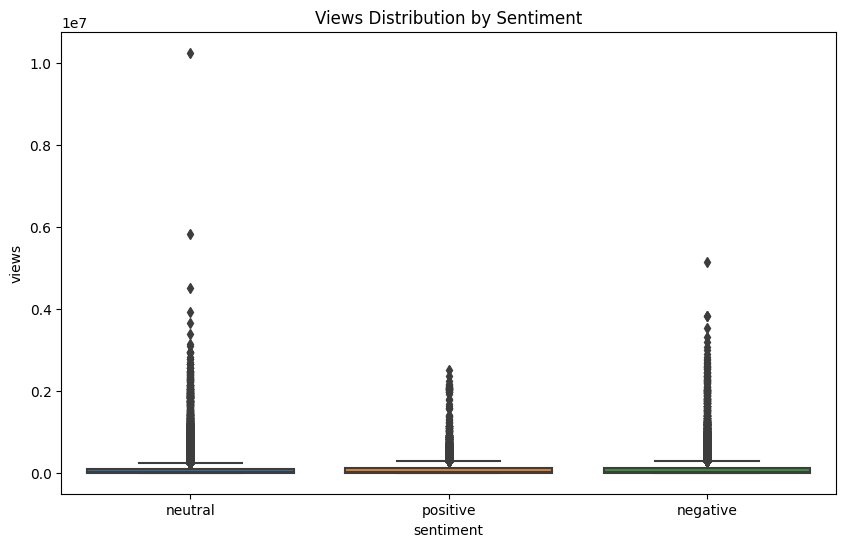

One-Way ANOVA Results:
F-statistic: 414.4870921596731
p-value: 1.2117112665659e-180
There is a statistically significant difference in views across sentiments

Spearman Correlation Analysis:
Correlation Coefficient: -0.03073414410487156
p-value: 4.822958222508559e-167
Significant negative correlation between sentiment and views


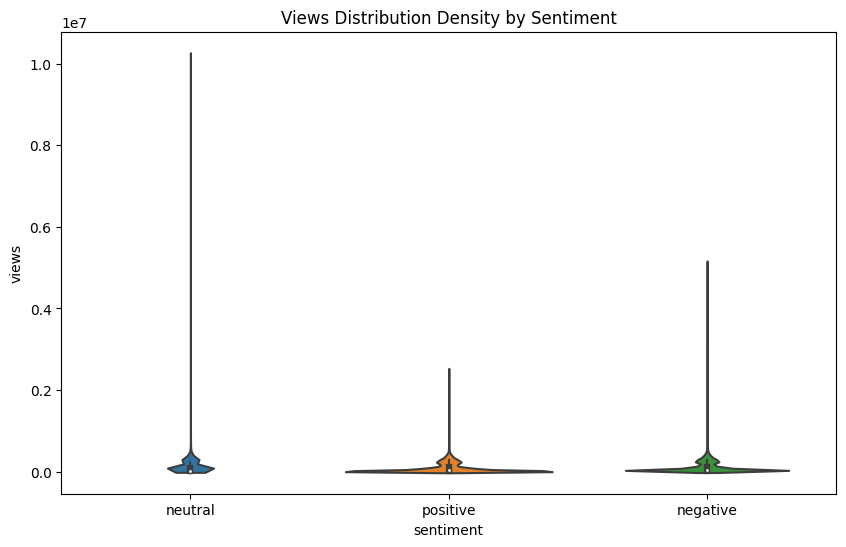


Percentage of High-View Messages by Sentiment:
sentiment
neutral     59.972203
negative    31.578187
positive     8.449610
Name: proportion, dtype: float64


In [6]:
main_analysis(seed_df)

Descriptive Statistics of Views by Sentiment:
             count           mean            std    min      25%      50%  \
sentiment                                                                   
negative   39534.0  230130.670689  324596.917413    0.0  11924.0  31921.0   
neutral    67895.0  277948.891391  342155.463026   67.0  15064.5  77908.0   
positive   15945.0  119314.208592  216401.299052  168.0  13285.0  27659.0   

                 75%        max  
sentiment                        
negative   558934.75  3563231.0  
neutral    668063.50  3546938.0  
positive   102783.00  2679657.0  


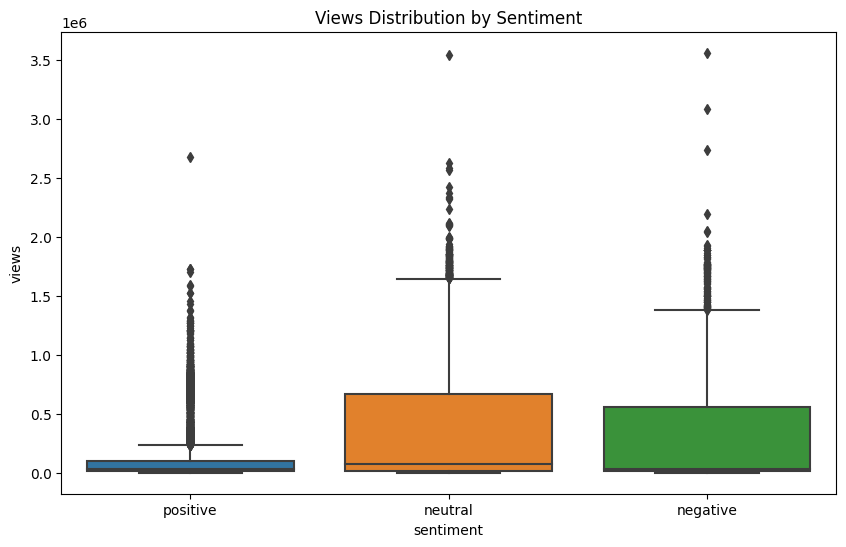

One-Way ANOVA Results:
F-statistic: 1598.747953058241
p-value: 0.0
There is a statistically significant difference in views across sentiments

Spearman Correlation Analysis:
Correlation Coefficient: -0.00842254759641227
p-value: 0.0030922890608891386
Significant negative correlation between sentiment and views


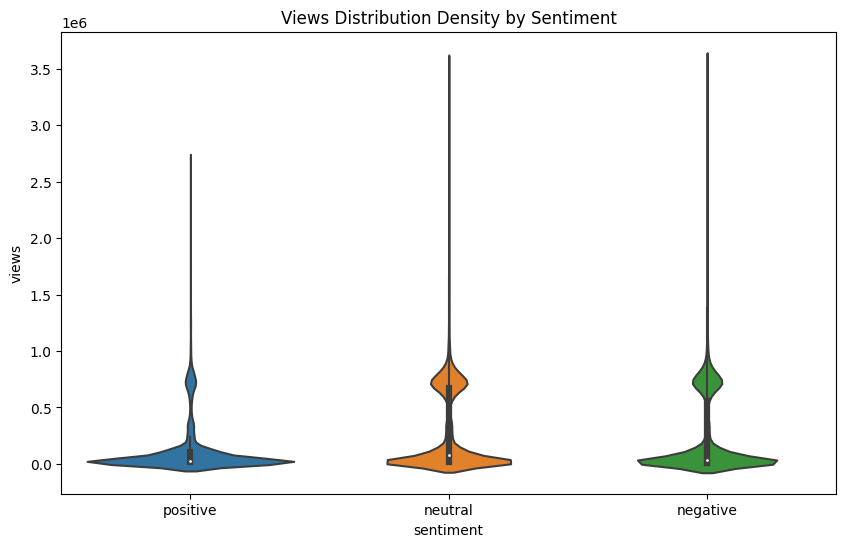


Percentage of High-View Messages by Sentiment:
sentiment
neutral     64.848917
negative    30.923356
positive     4.227727
Name: proportion, dtype: float64


In [9]:
main_analysis(bridge_df)

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scipy.stats as stats

class EmotionViewsAnalysis:
    def __init__(self, dataframe):
        self.df = dataframe
        
    def descriptive_statistics(self):
        """
        Provides descriptive statistics of views grouped by emotion
        """
        print("--- Descriptive Statistics of Views by Emotion ---")
        emotion_views_stats = self.df.groupby('emotion').agg({
            'views': [
                ('count', 'count'),
                ('median', 'median'),
                ('mean', 'mean'),
                ('std', 'std'),
                ('25%', lambda x: x.quantile(0.25)),
                ('75%', lambda x: x.quantile(0.75))
            ]
        })
        
        print(emotion_views_stats)
        
        # Visualization of median views
        plt.figure(figsize=(12,6))
        emotion_views_stats[('views', 'median')].plot(kind='bar')
        plt.title('Median Views by Emotion')
        plt.xlabel('Emotion')
        plt.ylabel('Median Views')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    
    def boxplot_analysis(self):
        """
        Creates a box plot to visualize views distribution across emotions
        """
        plt.figure(figsize=(12,6))
        sns.boxplot(x='emotion', y='views', data=self.df)
        plt.title('Views Distribution by Emotion')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    
    def anova_test(self):
        """
        Performs one-way ANOVA to test if views differ significantly across emotions
        """
        print("\n--- One-Way ANOVA Test ---")
        
        # Separate views for each emotion
        emotion_groups = [self.df[self.df['emotion'] == emotion]['views'] for emotion in self.df['emotion'].unique()]
        
        # Perform one-way ANOVA
        f_statistic, p_value = stats.f_oneway(*emotion_groups)
        
        print("ANOVA Results:")
        print(f"F-statistic: {f_statistic}")
        print(f"p-value: {p_value}")
        
        # Interpretation
        if p_value < 0.05:
            print("There is a statistically significant difference in views across emotions")
        else:
            print("No statistically significant difference in views across emotions")
    
    def correlation_analysis(self):
        """
        Performs correlation analysis between emotions and views
        """
        print("\n--- Correlation Analysis ---")
        
        # Create numeric mapping for emotions
        emotion_map = {
            'joy': 1, 
            'love': 2, 
            'surprise': 3, 
            'sadness': -1, 
            'anger': -2, 
            'fear': -3
        }
        
        # Convert emotions to numeric
        self.df['emotion_numeric'] = self.df['emotion'].map(emotion_map)
        
        # Calculate Spearman correlation
        correlation, p_value = stats.spearmanr(self.df['emotion_numeric'], self.df['views'])
        
        print("Spearman Correlation Analysis:")
        print(f"Correlation Coefficient: {correlation}")
        print(f"p-value: {p_value}")
        
        # Interpretation
        if p_value < 0.05:
            if correlation > 0:
                print("Significant positive correlation between emotion and views")
            elif correlation < 0:
                print("Significant negative correlation between emotion and views")
        else:
            print("No significant correlation between emotion and views")
    
    def violin_plot(self):
        """
        Creates a violin plot to show views distribution and density by emotion
        """
        plt.figure(figsize=(12,6))
        sns.violinplot(x='emotion', y='views', data=self.df)
        plt.title('Views Distribution Density by Emotion')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    
    def high_views_percentage(self):
        """
        Analyzes the percentage of high-view messages by emotion
        """
        print("\n--- High Views Percentage by Emotion ---")
        
        # Define high views (above 75th percentile)
        high_views_threshold = self.df['views'].quantile(0.75)
        
        # Filter high view messages
        high_views_df = self.df[self.df['views'] >= high_views_threshold]
        
        # Calculate percentage
        high_views_percentage = high_views_df['emotion'].value_counts(normalize=True) * 100
        
        print("Percentage of High-View Messages by Emotion:")
        print(high_views_percentage)
        
        # Visualization
        plt.figure(figsize=(10,6))
        high_views_percentage.plot(kind='bar')
        plt.title('Percentage of High-View Messages by Emotion')
        plt.xlabel('Emotion')
        plt.ylabel('Percentage of High-View Messages')
        plt.tight_layout()
        plt.show()
    
    def pairwise_comparisons(self):
        """
        Performs pairwise t-tests between emotions
        """
        print("\n--- Pairwise Comparisons ---")
        emotions = self.df['emotion'].unique()
        
        print("Pairwise T-Test Results:")
        for i in range(len(emotions)):
            for j in range(i+1, len(emotions)):
                emotion1 = emotions[i]
                emotion2 = emotions[j]
                
                views1 = self.df[self.df['emotion'] == emotion1]['views']
                views2 = self.df[self.df['emotion'] == emotion2]['views']
                
                t_stat, p_val = stats.ttest_ind(views1, views2)
                
                print(f"{emotion1} vs {emotion2}:")
                print(f"t-statistic: {t_stat}")
                print(f"p-value: {p_val}")
                print("Significant" if p_val < 0.05 else "Not Significant")
                print()
    
    def run_full_analysis(self):
        """
        Executes all analyses
        """
        self.descriptive_statistics()
        self.boxplot_analysis()
        self.anova_test()
        self.correlation_analysis()
        self.violin_plot()
        self.high_views_percentage()
        self.pairwise_comparisons()

--- Descriptive Statistics of Views by Emotion ---
           views                                                           
           count   median          mean            std       25%        75%
emotion                                                                    
anger      19479  38196.0  86477.473330  128590.975468   4221.00  100480.50
fear         595  41772.0  79795.868908  112460.457625   4301.00   78182.00
joy       782820  25159.0  84509.695456  127918.139187   3488.00  104482.25
love          11   4161.0  24858.272727   47745.822439   2984.50   19528.50
sadness       62   4057.0  46347.838710  106644.816068   3205.25   27903.25
surprise       2  30588.5  30588.500000   20390.838249  23379.25   37797.75


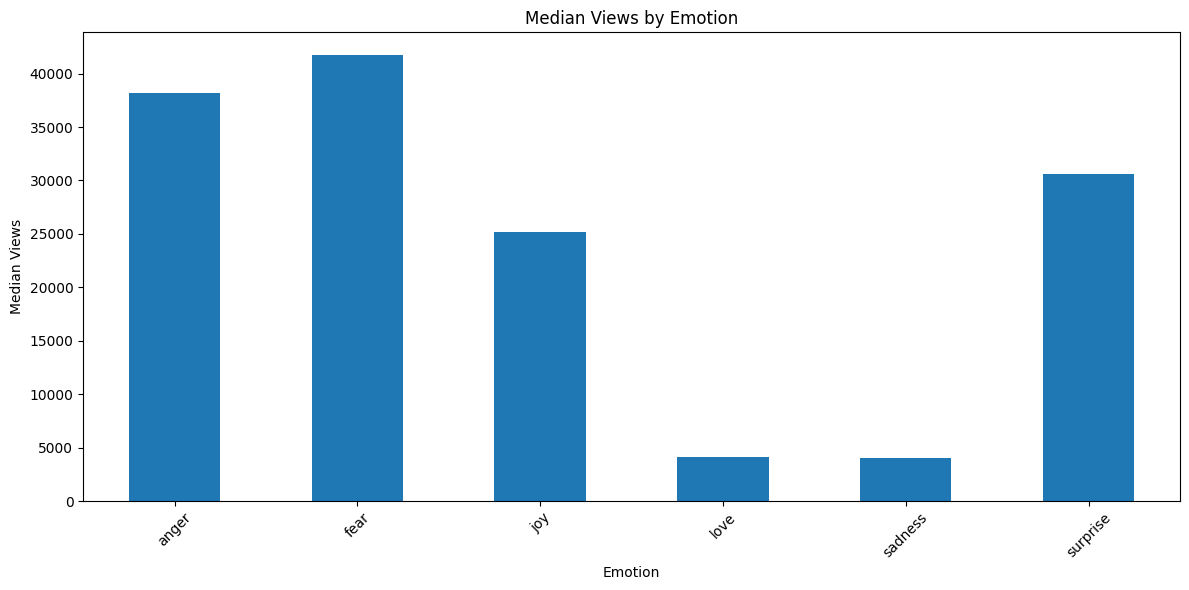

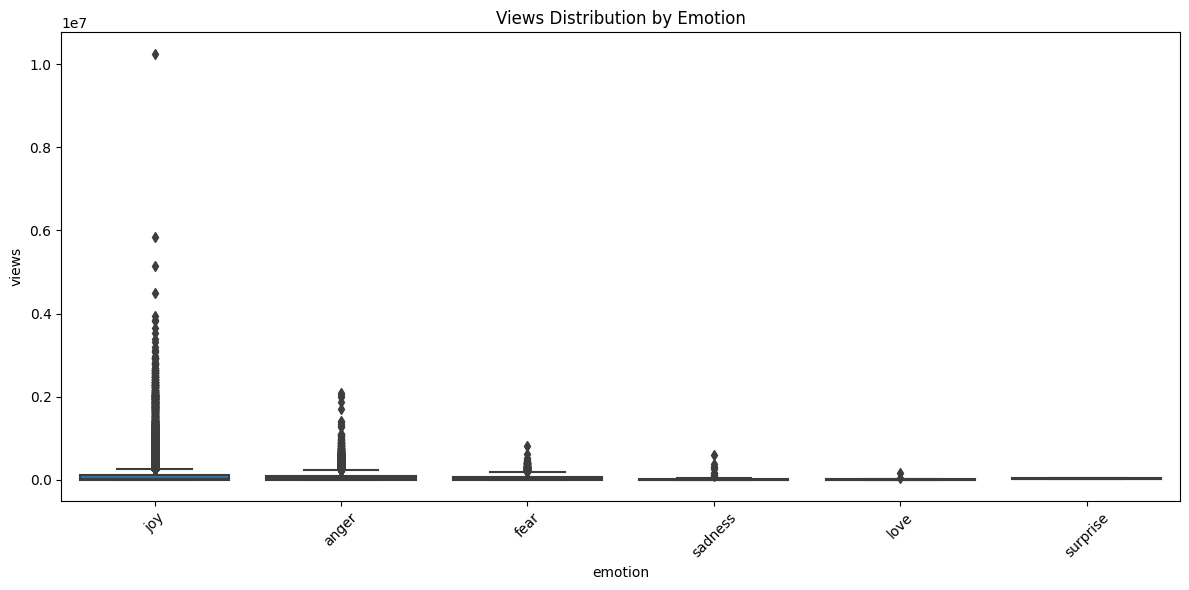


--- One-Way ANOVA Test ---
ANOVA Results:
F-statistic: 2.7204751865739607
p-value: 0.018343221694989833
There is a statistically significant difference in views across emotions

--- Correlation Analysis ---
Spearman Correlation Analysis:
Correlation Coefficient: -0.010655432267281308
p-value: 1.31672514157396e-21
Significant negative correlation between emotion and views


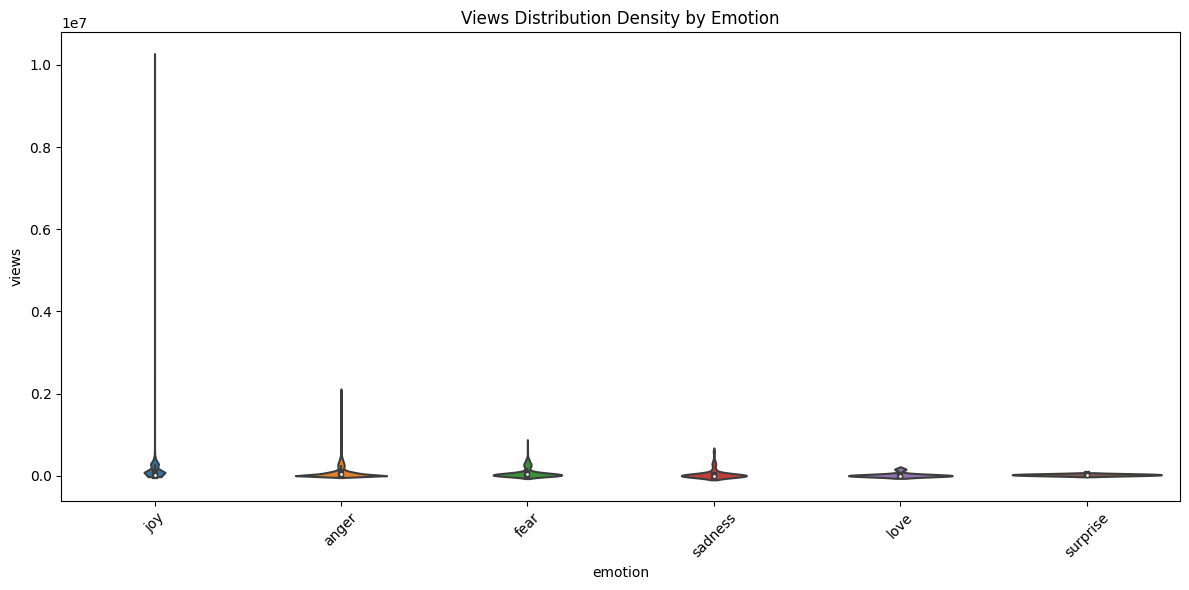


--- High Views Percentage by Emotion ---
Percentage of High-View Messages by Emotion:
emotion
joy        97.577001
anger       2.357741
fear        0.060774
sadness     0.003985
love        0.000498
Name: proportion, dtype: float64


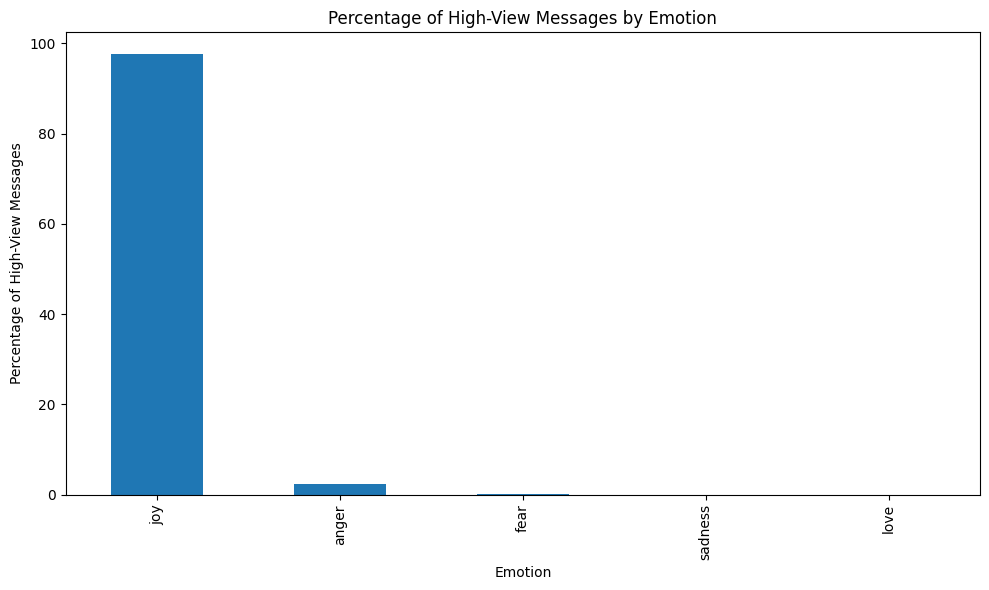


--- Pairwise Comparisons ---
Pairwise T-Test Results:
joy vs anger:
t-statistic: -2.1204815692478274
p-value: 0.03396576018461727
Significant

joy vs fear:
t-statistic: 0.8986122889381848
p-value: 0.3688594868888738
Not Significant

joy vs sadness:
t-statistic: 2.3489900148777996
p-value: 0.01882465878725508
Significant

joy vs love:
t-statistic: 1.546622599815096
p-value: 0.12195468107102006
Not Significant

joy vs surprise:
t-statistic: 0.5961315295432058
p-value: 0.5510875348404953
Not Significant

anger vs fear:
t-statistic: 1.2528857859327038
p-value: 0.21026187105711897
Not Significant

anger vs sadness:
t-statistic: 2.4545520800448757
p-value: 0.014114679847723638
Significant

anger vs love:
t-statistic: 1.5891884741833113
p-value: 0.11203406961370364
Not Significant

anger vs surprise:
t-statistic: 0.6146377242191864
p-value: 0.5388011745452463
Not Significant

fear vs sadness:
t-statistic: 2.2391822525388165
p-value: 0.025478964016934013
Significant

fear vs love:
t-statistic

In [22]:
emotion_analysis = EmotionViewsAnalysis(seed_df)
emotion_analysis.run_full_analysis()

In [18]:
seed_df['toxicity'].unique()

array(['non_toxic', 'toxic', 'obscene', 'identity_hate', 'insult',
       'threat'], dtype=object)

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

class ToxicityViewsAnalysis:
    def __init__(self, dataframe):
        self.df = dataframe
        
    def descriptive_statistics(self):
        """
        Provides descriptive statistics of views grouped by toxicity
        Uses median instead of mean to reduce outlier impact
        """
        print("--- Descriptive Statistics of Views by Toxicity ---")
        
        # Detailed statistics with median emphasis
        toxicity_views_stats = self.df.groupby('toxicity').agg({
            'views': [
                ('count', 'count'),
                ('median', 'median'),
                ('mean', 'mean'),
                ('std', 'std'),
                ('25%', lambda x: x.quantile(0.25)),
                ('75%', lambda x: x.quantile(0.75))
            ]
        })
        print(toxicity_views_stats)
        
        # Visualization of median views
        plt.figure(figsize=(12,6))
        toxicity_views_stats[('views', 'median')].plot(kind='bar')
        plt.title('Median Views by Toxicity Level')
        plt.xlabel('Toxicity')
        plt.ylabel('Median Views')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    
    def robust_boxplot_analysis(self):
        """
        Creates a box plot with log-transformed views to handle outliers
        """
        plt.figure(figsize=(12,6))
        
        # Create a copy of the dataframe with log-transformed views
        df_log = self.df.copy()
        df_log['log_views'] = np.log1p(df_log['views'])
        
        # Box plot of log-transformed views
        sns.boxplot(x='toxicity', y='log_views', data=df_log)
        plt.title('Log-Transformed Views Distribution by Toxicity')
        plt.xlabel('Toxicity')
        plt.ylabel('Log(Views + 1)')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    
    def non_parametric_anova(self):
        """
        Performs Kruskal-Wallis H-test (non-parametric alternative to ANOVA)
        """
        print("\n--- Kruskal-Wallis H-Test ---")
        
        # Prepare views for each toxicity level
        toxicity_groups = [
            self.df[self.df['toxicity'] == tox]['views'] 
            for tox in self.df['toxicity'].unique()
        ]
        
        # Perform Kruskal-Wallis H-test
        h_statistic, p_value = stats.kruskal(*toxicity_groups)
        
        print("Kruskal-Wallis Test Results:")
        print(f"H-statistic: {h_statistic}")
        print(f"p-value: {p_value}")
        
        # Interpretation
        if p_value < 0.05:
            print("There is a statistically significant difference in views across toxicity levels")
        else:
            print("No statistically significant difference in views across toxicity levels")
    
    def correlation_and_ranking_analysis(self):
        """
        Performs correlation analysis with a custom toxicity ranking
        """
        print("\n--- Toxicity-Views Correlation Analysis ---")
        
        # Create a numeric mapping for toxicity levels
        toxicity_map = {
            'non_toxic': 0,
            'insult': 1,
            'obscene': 2,
            'threat': 3,
            'identity_hate': 4,
            'toxic': 5
        }
        
        # Convert toxicity to numeric
        self.df['toxicity_numeric'] = self.df['toxicity'].map(toxicity_map)
        
        # Perform Spearman correlation (robust to non-linear relationships)
        correlation, p_value = stats.spearmanr(self.df['toxicity_numeric'], self.df['views'])
        
        print("Spearman Correlation Analysis:")
        print(f"Correlation Coefficient: {correlation}")
        print(f"p-value: {p_value}")
        
        # Interpretation
        if p_value < 0.05:
            if correlation > 0:
                print("Significant positive correlation between toxicity and views")
            else:
                print("Significant negative correlation between toxicity and views")
        else:
            print("No significant correlation between toxicity and views")
    
    def advanced_distribution_analysis(self):
        """
        Creates a violin plot and kernel density estimation
        """
        plt.figure(figsize=(14,7))
        
        # Subplot 1: Violin Plot
        plt.subplot(1,2,1)
        sns.violinplot(x='toxicity', y='views', data=self.df)
        plt.title('Views Distribution by Toxicity')
        plt.xticks(rotation=45, ha='right')
        
        # Subplot 2: Kernel Density Estimation
        plt.subplot(1,2,2)
        for tox in self.df['toxicity'].unique():
            sns.kdeplot(
                self.df[self.df['toxicity'] == tox]['views'], 
                label=tox
            )
        plt.title('Kernel Density of Views by Toxicity')
        plt.legend()
        
        plt.tight_layout()
        plt.show()
    
    def high_views_toxicity_analysis(self):
        """
        Analyzes the percentage of high-view messages by toxicity
        Uses median as threshold to reduce outlier impact
        """
        print("\n--- High Views Percentage by Toxicity ---")
        
        # Define high views threshold using median
        high_views_threshold = self.df['views'].median()
        
        # Filter high view messages
        high_views_df = self.df[self.df['views'] >= high_views_threshold]
        
        # Calculate percentage
        high_views_percentage = high_views_df['toxicity'].value_counts(normalize=True) * 100
        
        print("Percentage of High-View Messages by Toxicity:")
        print(high_views_percentage)
        
        # Visualization
        plt.figure(figsize=(10,6))
        high_views_percentage.plot(kind='bar')
        plt.title('Percentage of High-View Messages by Toxicity')
        plt.xlabel('Toxicity')
        plt.ylabel('Percentage of High-View Messages')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    
    def pairwise_comparisons(self):
        """
        Performs pairwise Mann-Whitney U tests between toxicity levels
        """
        print("\n--- Pairwise Comparisons (Mann-Whitney U Test) ---")
        toxicities = self.df['toxicity'].unique()
        
        print("Pairwise Mann-Whitney U Test Results:")
        for i in range(len(toxicities)):
            for j in range(i+1, len(toxicities)):
                tox1 = toxicities[i]
                tox2 = toxicities[j]
                
                views1 = self.df[self.df['toxicity'] == tox1]['views']
                views2 = self.df[self.df['toxicity'] == tox2]['views']
                
                u_stat, p_val = stats.mannwhitneyu(views1, views2, alternative='two-sided')
                
                print(f"{tox1} vs {tox2}:")
                print(f"U-statistic: {u_stat}")
                print(f"p-value: {p_val}")
                print("Significant" if p_val < 0.05 else "Not Significant")
                print()
    
    def run_full_analysis(self):
        """
        Executes all analyses
        """
        self.descriptive_statistics()
        self.robust_boxplot_analysis()
        self.non_parametric_anova()
        self.correlation_and_ranking_analysis()
        self.advanced_distribution_analysis()
        self.high_views_toxicity_analysis()
        self.pairwise_comparisons()

--- Descriptive Statistics of Views by Toxicity ---
                views                                                  \
                count   median          mean            std       25%   
toxicity                                                                
identity_hate       1   3920.0   3920.000000            NaN   3920.00   
insult              2  26380.5  26380.500000   18785.705856  19738.75   
non_toxic      802306  25342.0  84596.427949  127942.507530   3525.00   
obscene           171   4722.0  46227.187135   91579.838792   3525.50   
threat              1  38610.0  38610.000000            NaN  38610.00   
toxic             488   4095.0  22211.811475   79652.955165   3488.75   

                          
                     75%  
toxicity                  
identity_hate    3920.00  
insult          33022.25  
non_toxic      104429.75  
obscene         43735.00  
threat          38610.00  
toxic            5074.50  


/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


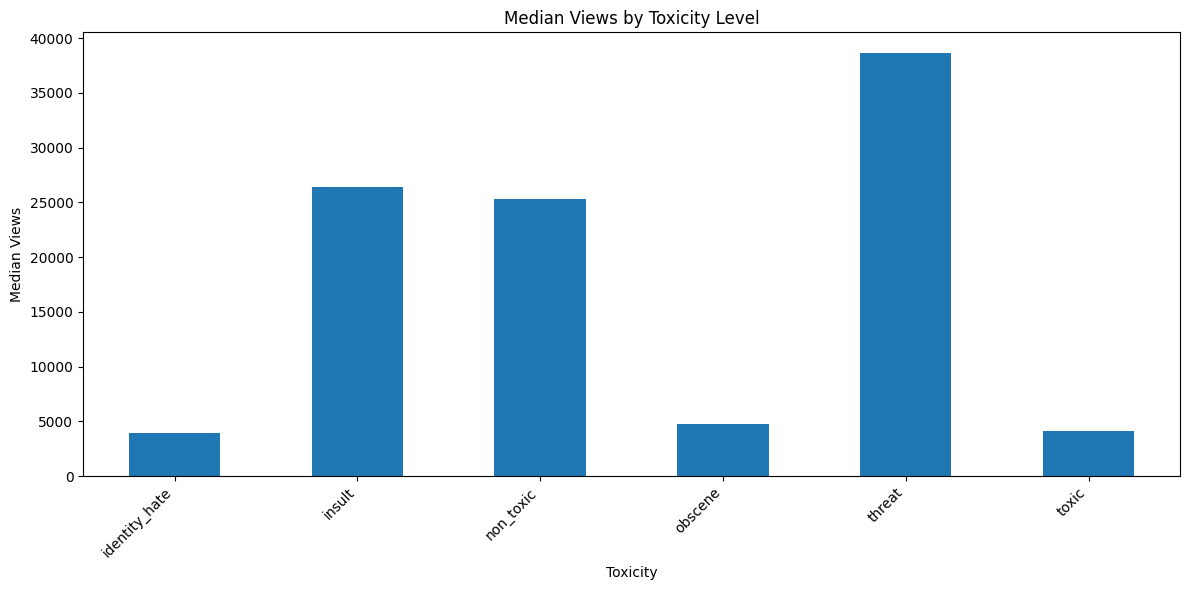

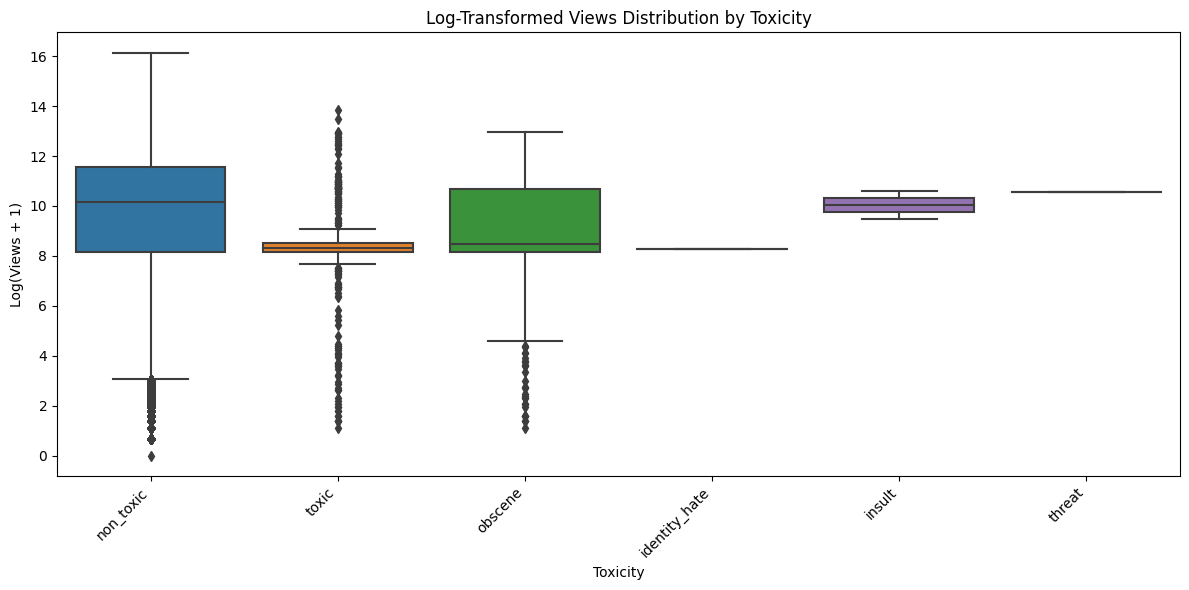


--- Kruskal-Wallis H-Test ---
Kruskal-Wallis Test Results:
H-statistic: 264.43510611589153
p-value: 4.383907973400158e-55
There is a statistically significant difference in views across toxicity levels

--- Toxicity-Views Correlation Analysis ---
Spearman Correlation Analysis:
Correlation Coefficient: -0.01779389120525368
p-value: 3.033345893004343e-57
Significant negative correlation between toxicity and views


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

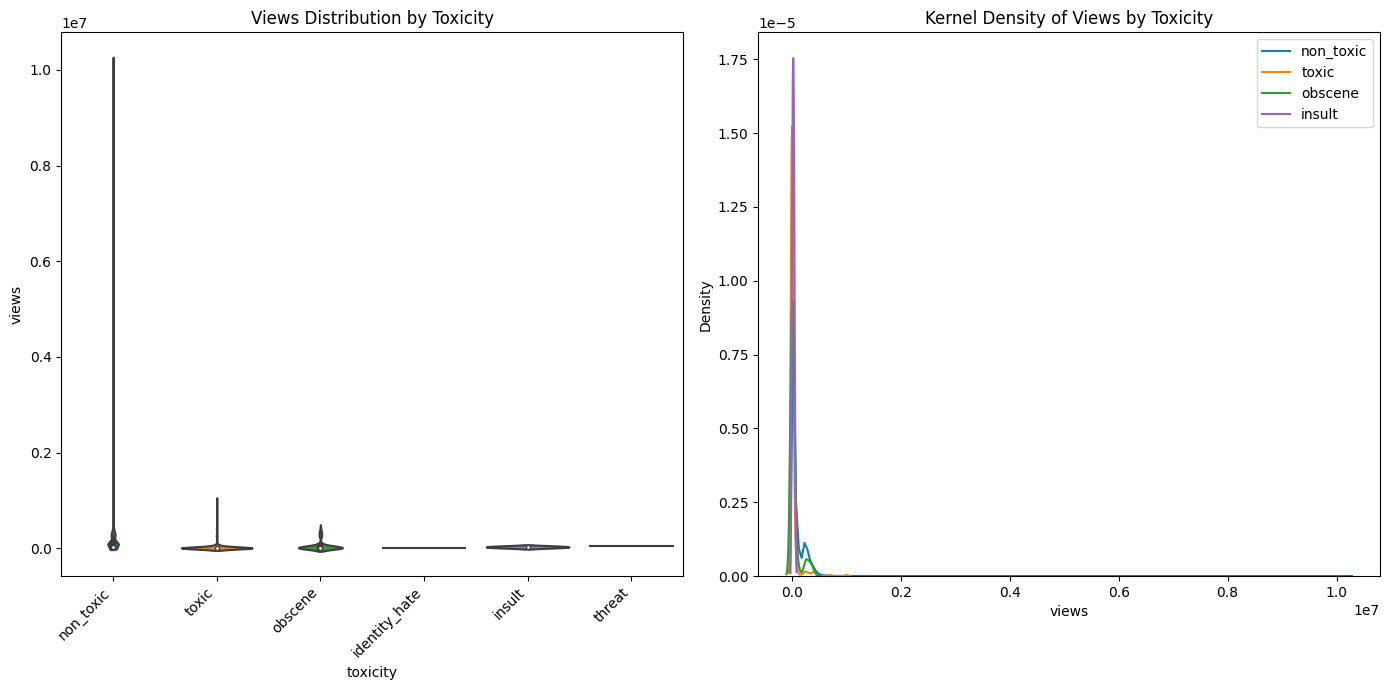


--- High Views Percentage by Toxicity ---
Percentage of High-View Messages by Toxicity:
toxicity
non_toxic    99.970112
toxic         0.015691
obscene       0.013699
threat        0.000249
insult        0.000249
Name: proportion, dtype: float64


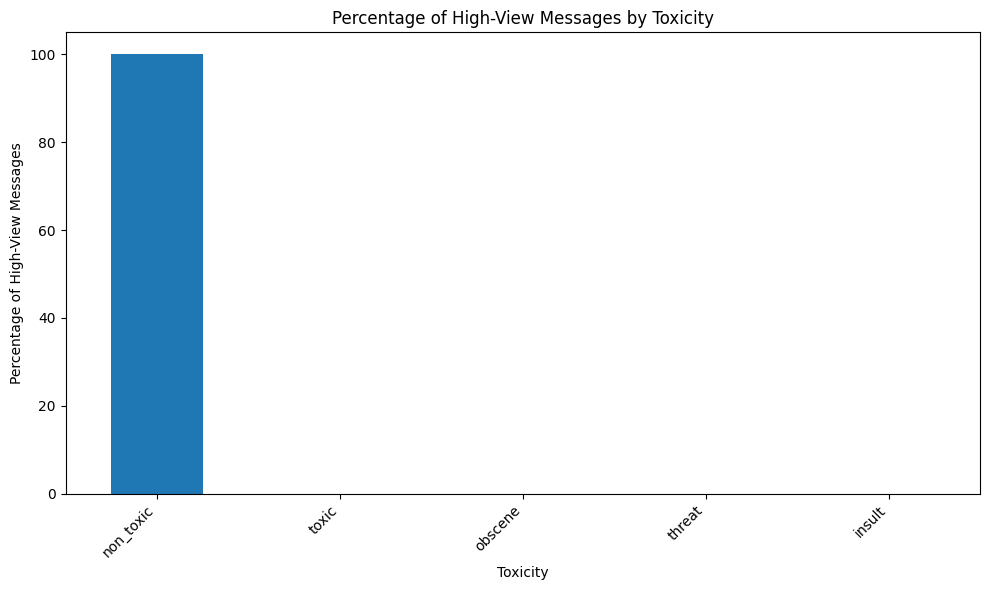


--- Pairwise Comparisons (Mann-Whitney U Test) ---
Pairwise Mann-Whitney U Test Results:
non_toxic vs toxic:
U-statistic: 273900205.5
p-value: 1.2589257974183577e-52
Significant

non_toxic vs obscene:
U-statistic: 85351823.0
p-value: 3.1753318677293946e-08
Significant

non_toxic vs identity_hate:
U-statistic: 591810.0
p-value: 0.4103981976489287
Not Significant

non_toxic vs insult:
U-statistic: 890912.5
p-value: 0.7867609108522329
Not Significant

non_toxic vs threat:
U-statistic: 350409.0
p-value: 0.8265768108107523
Not Significant

toxic vs obscene:
U-statistic: 34247.5
p-value: 0.0004836749190808353
Significant

toxic vs identity_hate:
U-statistic: 279.5
p-value: 0.8041788630801143
Not Significant

toxic vs insult:
U-statistic: 127.0
p-value: 0.07123519775835788
Not Significant

toxic vs threat:
U-statistic: 54.0
p-value: 0.17945605159617206
Not Significant

obscene vs identity_hate:
U-statistic: 113.0
p-value: 0.5865822268990177
Not Significant

obscene vs insult:
U-statistic: 12

In [20]:
toxicity_analysis = ToxicityViewsAnalysis(seed_df)
toxicity_analysis.run_full_analysis()